## Code to show the number of datasets per Organ + AS, by sex and CTann tool

## Install and import libraries

In [1]:
%pip install pandas seaborn matplotlib requests numpy


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import requests
import io
from io import StringIO
import numpy as np
from matplotlib.ticker import FuncFormatter



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Load data

In [2]:
# could also use https://apps.humanatlas.io/api/grlc/hra-pop.html#get-/cell-types-in-atlas
url = f"https://raw.githubusercontent.com/x-atlas-consortia/hra-pop/refs/heads/main/output-data/v1.0/reports/atlas-ad-hoc/cell-types-in-anatomical-structurescts-per-as.csv"

headers = {"Accept": "text/csv"}

data = requests.get(url=url, headers=headers).text

df = pd.read_csv(StringIO(data))
df


,organ,as,as_label,sex,tool,modality,cell_id,cell_label,cell_count,cell_percentage,dataset_count
0,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_colonocyte,Colonocyte,1.205,0.147653,3
1,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_iga-plasma-cell,IgA plasma cell,1.182,0.144835,3
2,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_best4-epithelial,BEST4+ epithelial,0.699,0.085651,3
3,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_activated-cd4-t,Activated CD4 T,0.690,0.084548,3
4,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_ta,TA,0.540,0.066168,3
...,...,...,...,...,...,...,...,...,...,...,...
8891,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,sc_proteomics,sc_proteomics,http://purl.obolibrary.org/obo/CL_0000097,Mast Cell,15322.464,0.024702,1
8892,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,sc_proteomics,sc_proteomics,http://purl.obolibrary.org/obo/CL_4033039,CD8+ T Cell,3691.176,0.005951,1
8893,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,sc_proteomics,sc_proteomics,https://purl.org/ccf/ASCTB-TEMP_lymphatic-endo...,Lymphatic Endothelial (and some immune cells),1753.956,0.002828,1
8894,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,sc_proteomics,sc_proteomics,https://purl.org/ccf/ASCTB-TEMP_basal-epitheli...,Basal Epithelial Cell,970.104,0.001564,1


## Preprocess data

In [3]:
df[["organ", "as_label"]] = df[["organ", "as_label"]].apply(
    lambda col: col.str.strip().str.lower()
)

df["organ"] = df["organ"].replace(
    {
        "left mammary gland": "left breast",
        "right mammary gland": "right breast",
        "male reproductive system": "prostate",
    }
)

In [4]:
# de-duplicate, group, and sum dataset_count
df_dedup = df.drop_duplicates(subset=["organ", "as_label", "sex", "tool", "modality"])

agg = df_dedup.groupby(["organ", "as_label", "sex"], as_index=False)[
    "dataset_count"
].sum()


pyramid_df = agg.pivot_table(
    index=["organ", "as_label"], columns="sex", values="dataset_count", fill_value=0
).reset_index()

pyramid_df["Male"] = -pyramid_df.get("Male", 0)
pyramid_df["Female"] = pyramid_df.get("Female", 0)

pyramid_df["organ_as"] = pyramid_df["organ"] + " - " + pyramid_df["as_label"]

pyramid_df["total"] = pyramid_df["Female"] + pyramid_df["Male"].abs()

# pyramid_df = pyramid_df.sort_values("total")
pyramid_df = pyramid_df.sort_values("organ_as", ascending=False)

## Visualize

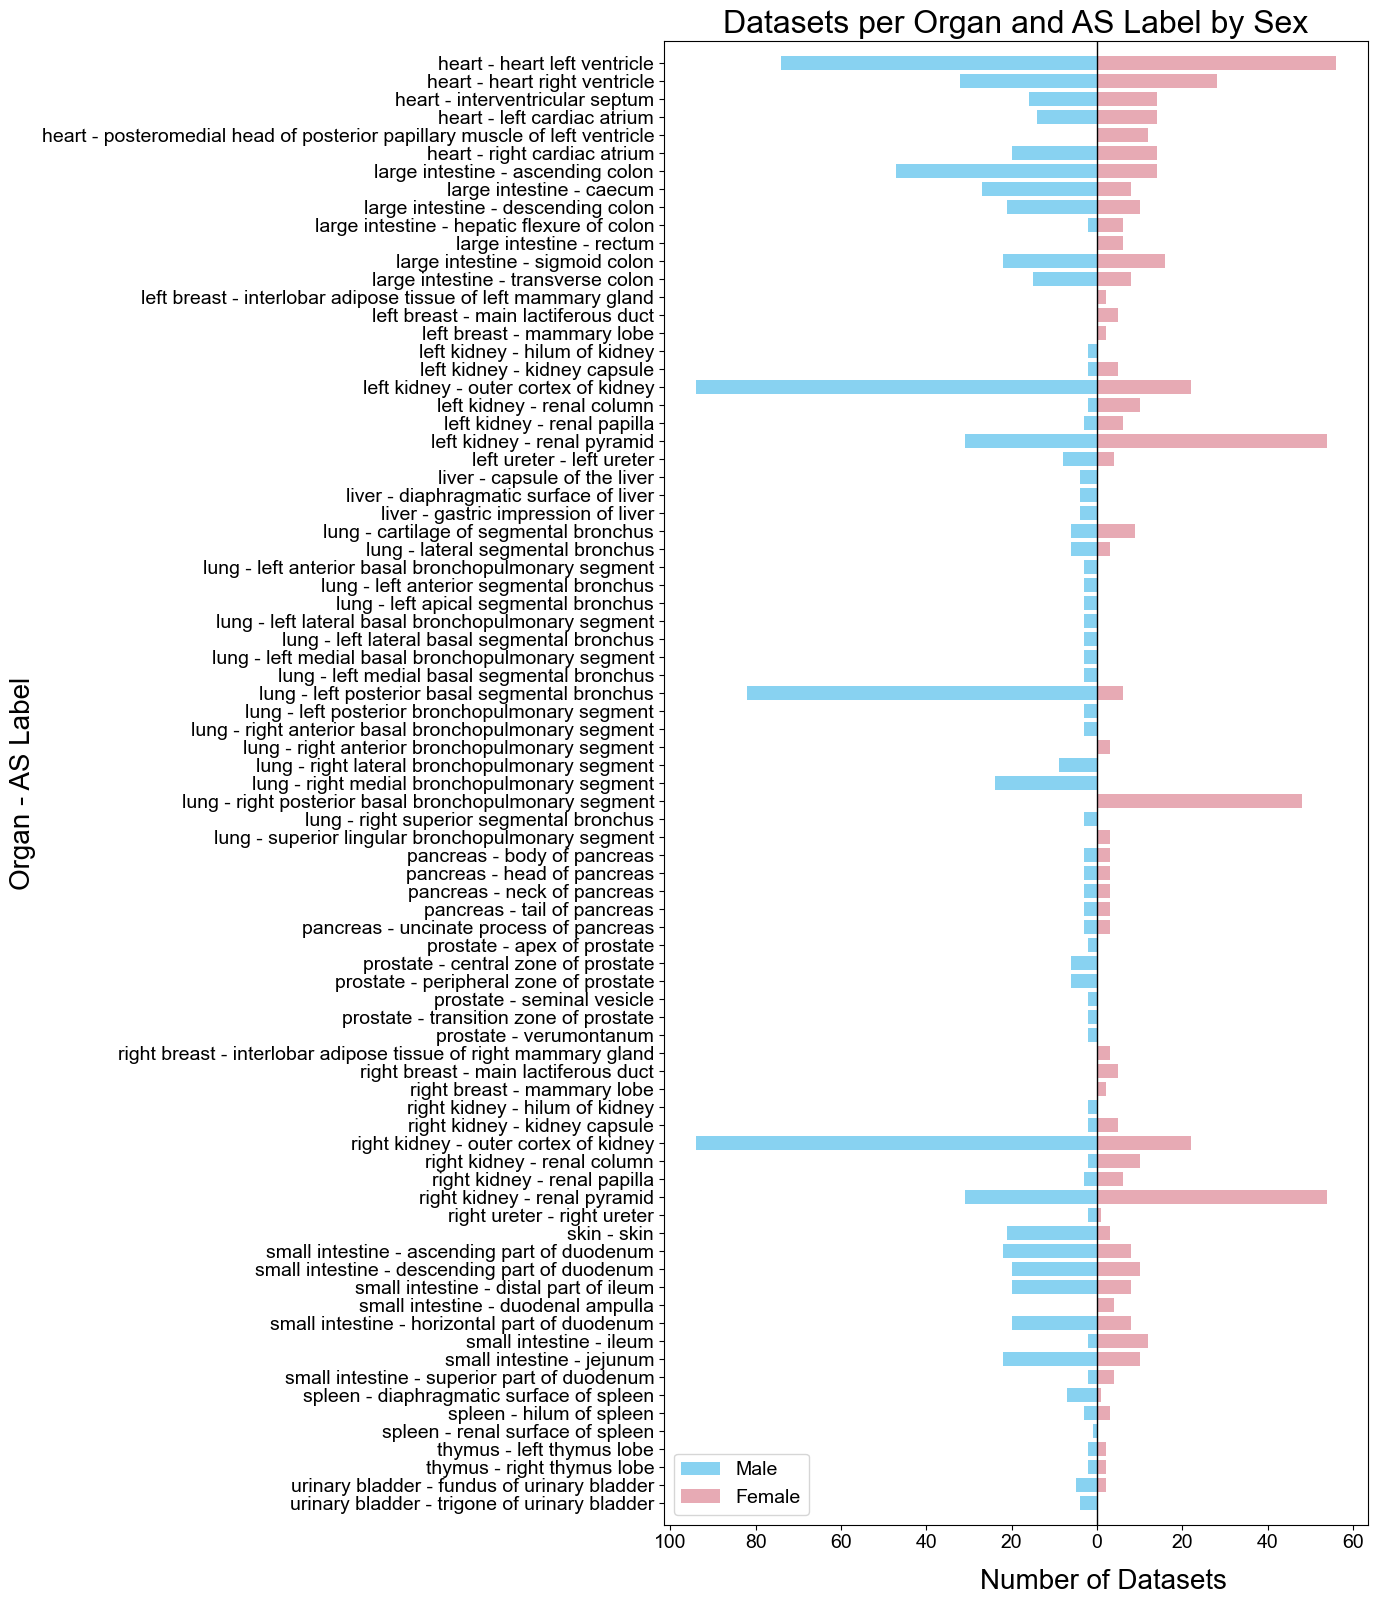

In [5]:
# ---- Global styling ----
plt.rcParams.update(
    {
        "font.family": "Arial",  
        "font.size": 14,
        "axes.titlesize": 23,
        "axes.labelsize": 20,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
    }
)

# ---- Sort data ----
pyramid_df["total"] = pyramid_df["Female"] + pyramid_df["Male"].abs()
# pyramid_df = pyramid_df.sort_values("total")

# ---- Figure ----
fig, ax = plt.subplots(figsize=(14, len(pyramid_df) * 0.2))

# Bars
ax.barh(pyramid_df["organ_as"], pyramid_df["Male"], color="#88d2f1", label="Male")
ax.barh(pyramid_df["organ_as"], pyramid_df["Female"], color="#e7aab4", label="Female")

# Center line
ax.axvline(0, linewidth=1, color="#000000")

# Set x-axis ticks and labels
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: int(abs(x))))

# Remove margins
ax.margins(y=.01)

# Labels
ax.set_xlabel("Number of Datasets")
# Move label to the right
ax.xaxis.set_label_coords(0.8, -0.03)
ax.xaxis.label.set_horizontalalignment("right")

ax.set_ylabel("Organ - AS Label")
ax.set_title("Datasets per Organ and AS Label by Sex")

ax.legend(loc="best")

plt.tight_layout()

plt.savefig("output/Fig. 6.pdf", dpi=600)
plt.savefig("output/Fig. 6.png", dpi=600)
plt.show()
